In [1]:
import pandas as pd
from pandarallel import pandarallel
import pyarrow
import numpy as np
import spacy
from spacy import displacy
from spacy.matcher import Matcher, PhraseMatcher
from spacy.util import filter_spans
import json
import re
import warnings
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import pickle

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from snownlp import SnowNLP

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

load_dotenv()

# see section Aspect Based Sentiment Analysis -> Analysis -> Weighing Title and Content
EN_TITLE_WEIGHT = 7.94
EN_CONTENT_WEIGHT = 356

ALPHA = 0.05

# list generated by Gemini
relevant_eng_deps = [
    'acomp',   # Adjectival complement (e.g., "is effective")
    'advmod',  # Adverbial modifier (e.g., "highly", "completely")
    'neg',     # Negation (e.g., "not", "never")
    'dobj',    # Direct object (e.g., "cleared the infection")
    'xcomp',   # Open clausal complement (e.g., "seems to work")
    'attr'     # Attribute (e.g., "is a scam")
]
relevant_chinese_deps = [
    'acomp', 'advmod', 'neg', 'dobj', 'xcomp', 'attr', 'dep', 'aux:asp', 'amod'
]
clause_deps = ['conj', 'parataxis', 'ccomp']
anchor_pos = ['ADJ', 'VERB', 'AUX']

In [2]:
# for google colab
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from matplotlib import pyplot as plt
import os
from tqdm.notebook import tqdm
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"

from google.colab import drive
drive.mount('/content/drive')
os.chdir('drive/MyDrive/complit-4300')
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/complit-4300'

In [ ]:
# run once
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /home/reptiman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/reptiman/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/reptiman/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
with open("scraping/scrape_keywords/medicine_flattened.json") as file:
    keywords = json.load(file)

# Aspect Based Sentiment Analysis

## spaCy
- English model: [en_core_web_sm](https://spacy.io/models/en)
- Chinese model: [zh_core_web_sm](https://spacy.io/models/zh)

In [4]:
def nlp_factory(keywords, lang = "en"):
    if lang == "en":
        nlp = spacy.load("en_core_web_sm")
    else:
        nlp = spacy.load("zh_core_web_sm")
    return nlp

In [5]:
class custom_nlp():
    def __init__(self, keywords, lang='en'):
        self.keywords = keywords
        self.lang = lang
        self.nlp = nlp_factory(keywords, lang)
    
    def find_span(self, doc, keyword):
        if self.lang == "en":
            search_str = rf"(?i)\b{re.escape(keyword)}s*\b"
        else:
            search_str = re.escape(keyword)
        spans = []
        span_map = {}
        for match in re.finditer(search_str, doc.text):
            start_char, end_char = match.span()
            span = doc.char_span(start_char, end_char, alignment_mode="expand") # align to tokens that cover the whole sequence
            spans.append(span)
            span_map[span] = keyword
        return spans, span_map
    
    def __call__(self, text):
        doc = self.nlp(text)
        self.doc = doc
        spans = []
        span_maps = {}
        for keyword in self.keywords:
            cur_spans, span_map = self.find_span(doc, keyword)
            spans.extend(cur_spans)
            span_maps.update(span_map)
        # use the longest coverage
        spans = filter_spans(spans)
        with doc.retokenize() as retokenizer:
            for span in spans:
                lemma = span_maps.get(span, None)
                if lemma is None:
                    warnings.warn(f"Span <{span}> does not match any keyword.")
                retokenizer.merge(span, attrs={"LEMMA": lemma})
        return doc


In [6]:
nlp_dict = {
    "en": custom_nlp(keywords['en'], "en"),
    "zh": custom_nlp(keywords['cn'], "zh")
}

### QC

In [103]:
displacy.render(nlp_dict['en'](f"I used Mometasone furoate this morning"))

In [104]:
displacy.render(nlp_dict['en'](f"I used Danpifen Ruangao this morning"))

In [105]:
displacy.render(nlp_dict['en'](f"I used Danpifen this morning"))

In [106]:
nlp_dict['en'](f"I used Mometasone furoate this morning")[2].lemma_

'Mometasone furoate'

In [107]:
nlp_dict['en'](f"I used Mometasone furoate this morning")[2].dep_

'dobj'

In [108]:
displacy.render(nlp_dict['en']("Lianhua Qingwen Jiaonang was so bitter. I wanted to throw up. Yuck!!!"))

In [109]:
displacy.render(nlp_dict['en']("I forgot to put on my steroid creams before I left home for school this morning"))

In [110]:
displacy.render(nlp_dict['zh']("二型糖尿病是由于胰岛素抵抗导致的"))

In [111]:
displacy.render(nlp_dict['zh']("连花清瘟胶囊是治疗新冠的良药"))

In [112]:
%%timeit
nlp_dict['en']("Lianhua Qingwen Jiaonang was so bitter")

4.81 ms ± 368 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [113]:
%%timeit
nlp_dict['zh']("连花清瘟胶囊是治疗新冠的良药")

4.65 ms ± 692 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Sentence Parser

In [7]:
def prune_sentence_for_aspect(text, aspect, nlp):
    doc = nlp(text)
    target_tokens = []
    for token in doc:
        if token.lemma_ == aspect:
            target_tokens.append(token)

    pruned_sents = []
    for target_token in target_tokens:
        relevant_tokens = set()
        # add all modifiers of the aspect
        for sub_token in target_token.subtree:
            relevant_tokens.add(sub_token)

        # find the action word for the aspect
        anchor = target_token
        while anchor.head != anchor and anchor.pos_ not in anchor_pos:
            anchor = anchor.head
        relevant_tokens.add(anchor)

        # add all modifiers of the action anchor
        for child in anchor.children:
            if child.dep_ in (relevant_eng_deps if nlp.lang=='en' else relevant_chinese_deps):
                for sub_token in child.subtree:
                    relevant_tokens.add(sub_token)
        
        if nlp.lang == 'zh':
            # Grab result clauses that occur after the action anchor
            # dependents or siblings
            head_anchor = anchor
            for i in range(2):
                for child in head_anchor.children:
                    if child.dep_ in clause_deps and child.i > anchor.i:
                        for sub_token in child.subtree:
                            relevant_tokens.add(sub_token)
                if anchor.dep_ in clause_deps:
                    head_anchor = anchor.head
                else:
                    break

        # reconstruct the sentence
        sorted_tokens = sorted(list(relevant_tokens), key=lambda token: token.i)
        if nlp.lang == "en":
            pruned_sent = " ".join([token.text for token in sorted_tokens])
        else:
            pruned_sent = "".join([token.text for token in sorted_tokens])
        pruned_sents.append(pruned_sent)
        
    return pruned_sents

### QC

In [115]:
displacy.render(nlp_dict['en']('It was much more reliable than the Danpifen Ruangao prescribed by my TCM doctor.'))

In [146]:
text_1 = "The hospital waiting room was an absolute nightmare, but the topical steroids completely cleared my severe inflammations. It was much more reliable than the Danpifen Ruangao prescribed by my TCM doctor."
aspect_1 = "Danpifen Ruangao"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['en']))

text_2 = "To be honest, the Paeonol cream was not very effective for my back, but it was good for my knees."
aspect_2 = "Paeonol Cream"
print(prune_sentence_for_aspect(text_2, aspect_2, nlp_dict['en']))

['much more reliable the Danpifen Ruangao prescribed by my TCM doctor']
['the Paeonol cream was not very effective for my back']


In [145]:
text_2 = "To be honest, the Paeonol cream was not very effective for my back, but the doctors offering it were so sweet."
aspect_2 = "Paeonol Cream"
print(prune_sentence_for_aspect(text_2, aspect_2, nlp_dict['en']))

['the Paeonol cream was not very effective for my back']


In [140]:
displacy.render(nlp_dict['en']('To be honest, the Paeonol cream was not very effective for my back, but the doctors offering it were so sweet.'))

In [119]:
displacy.render(nlp_dict['zh']('我复方黄柏液都擦了一个多月了，一点用也没有'))

In [194]:
displacy.render(nlp_dict['zh']('发烧了吃什么中药，吃布洛芬，见效快。'))

In [199]:
displacy.render(nlp_dict['zh']('我去医院，医生就开了瓶复方黄柏液，态度差得不行'))

In [207]:
text_1 = "我复方黄柏液都擦了一个多月了，一点用也没有"
aspect_1 = "复方黄柏液"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['zh']))

text_2 = "发烧了吃什么中药，吃布洛芬，见效快。"
aspect_2 = "布洛芬"
print(prune_sentence_for_aspect(text_2, aspect_2, nlp_dict['zh']))

['我复方黄柏液都擦了一个多月一点用也没有']
['吃布洛芬见效快']


In [208]:
text_1 = "我复方黄柏液都擦了一个多月了，对我的湿疹有点用，但是还是不能完全治好"
aspect_1 = "复方黄柏液"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['zh']))

['我复方黄柏液都擦了一个多月，对我的湿疹有点用但是还是不能完全治好']


In [209]:
text_1 = "我去医院，医生就开了瓶复方黄柏液，态度差得不行"
aspect_1 = "复方黄柏液"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['zh']))

['就开了瓶复方黄柏液态度差得不行']


In [210]:
text_1 = "The doctors just prescribed me a steroid cream and were so rude to me"
aspect_1 = "Steroid cream"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['en']))

['just prescribed a steroid cream']


## Analysis

In [8]:
med_df = pd.read_csv("corpus/source_and_cleanup_metadata.csv")
med_df.head(2)

,id,ups,note_id,downs,search_keyword,poster,created_year,created_utc,shared_count,source,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
0,34344,37,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,0.0,Tresiba,2e65009b7023d6202cf0322ea037e3f9dccbad95d3d21a...,2025,1761778198,NaN,reddit,...,Insulin,diabetes,ebm,False,en,0.972991,en,0.831891,True,1.0
1,15129,1,d54273d76a9e58747c68f71e4416741a424e96fe835df5...,NaN,泰诺,ee3fb8546089cd65768e97fd7e37c69d9c34a25cae634d...,2026,1774688385,0.0,weibo,...,Acetaminophen,flu,ebm,False,zh,0.989413,NaN,NaN,True,1.0


In [9]:
med_df = med_df[['id', 'note_id', 'medicine_name', 'title_language', 'content_language']]
med_df.head(2)

,id,note_id,medicine_name,title_language,content_language
0,34344,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,Insulin,en,en
1,15129,d54273d76a9e58747c68f71e4416741a424e96fe835df5...,泰诺,NaN,zh


In [10]:
def parse_by_entry(note_id, medicine_name, title_lang, content_lang):
    note = pd.read_parquet(
        "corpus/cleaned/posts_by_noteid.parquet",
        filters=[('note_id', '==', note_id)]
    )
    if note.shape[0] != 1:
        warnings.warn(f"Matched {note.shape[0]} posts: note_id {note_id}")
    # remember we only looked at content for language identification when it was not null
    # assume title is in the same language as content -- this should be true most if not all of the times
    if title_lang != 'zh' and title_lang != 'en':
        title_lang = content_lang
    title_parsed = []
    content_parsed = []
    title = note['title'].iloc[0]
    if title == title: # not null
        title_parsed = prune_sentence_for_aspect(
            str(title),
            medicine_name,
            nlp_dict[title_lang]
        )
    content = note['content'].iloc[0]
    if content == content:
        content_parsed = prune_sentence_for_aspect(
            str(content),
            medicine_name,
            nlp_dict[content_lang]
        )
    return title_parsed, content_parsed

In [11]:
def parse_by_entry_store(series):
    title_parsed, content_parsed = parse_by_entry(
        series['note_id'], series['medicine_name'], series['title_language'], series['content_language']
    )
    return pd.Series({
        'title_parsed': title_parsed, 
        'content_parsed': content_parsed
    })
pandarallel.initialize(progress_bar=True)
med_df[['title_parsed', 'content_parsed']] = med_df.parallel_apply(parse_by_entry_store, axis=1)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [12]:
med_df.shape

(31430, 7)

In [13]:
# final deduplication
mask = med_df['title_parsed'].apply(lambda x: len(x)>0) | med_df['content_parsed'].apply(lambda x: len(x)>0)
med_df = med_df[mask]
med_df.shape

(26848, 7)

In [14]:
med_df.to_parquet('corpus/absa/parsed_cleaned_posts.parquet')

In [15]:
parsed_df = pd.read_parquet('corpus/absa/parsed_cleaned_posts.parquet')

### Weighing Title and Content

In [16]:
parsed_df['content_parsed'].apply(lambda x: len(x)>0).sum()

np.int64(26534)

In [17]:
en_df = parsed_df.query("content_language == 'en' | (content_language != content_language & title_language == 'en')")
en_df.head(2)

,id,note_id,medicine_name,title_language,content_language,title_parsed,content_parsed
0,34344,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,Insulin,en,en,[],"[n't sound any insulin I take, also see anothe..."
2,32408,943fd948016cb72ed1a224d4080501103e3888a5f95ec4...,Oseltamivir,en,en,[],[Oseltamivir be a good one to get hold of thou...


In [18]:
en_notes = pd.read_parquet(
    "corpus/cleaned/posts_by_noteid.parquet",
    filters = [('note_id', 'in', en_df.note_id)]
)

In [19]:
en_notes['title_len'] = en_notes['title'].apply(
    lambda x: len([token for token in word_tokenize(x) if token.isalnum()]) if x==x else 0
)
en_notes['content_len'] = en_notes['content'].apply(
    lambda x: len([token for token in word_tokenize(x) if token.isalnum()]) if x==x else 0
)

In [20]:
en_notes['title_len'].mean(), en_notes['content_len'].mean()

(np.float64(7.459104938271605), np.float64(277.9627700617284))

### English

In [21]:
def vader_sentiment_analyzer(series):
    content_scores = []
    title_scores = []
    if series['content_language'] == 'en':
        sia = SentimentIntensityAnalyzer()
        for sent in series['content_parsed']:
            content_scores.append(sia.polarity_scores(sent)['compound'])
    for sent in series['title_parsed']:
        title_scores.append(sia.polarity_scores(sent)['compound'])
    agg = [pd.NA, pd.NA]
    if len(content_scores)>0:
        agg[0] = np.mean(content_scores)
    if len(title_scores)>0:
        agg[1] = np.mean(title_scores)
    return pd.Series({
        "content_scores": agg[0],
        "title_scores": agg[1]
    })

In [22]:
en_df = parsed_df.query("content_language == 'en' | (content_language != content_language & title_language == 'en')").copy()

In [23]:
pandarallel.initialize(progress_bar=True)
en_df[['content_scores', 'title_scores']] = en_df.parallel_apply(
    vader_sentiment_analyzer, axis=1
)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [24]:
def summarize_score(series):
    ts = series['title_scores']
    cs = series['content_scores']
    if (not pd.isna(ts)) and (not pd.isna(cs)):
        return (ts * EN_TITLE_WEIGHT + cs * EN_CONTENT_WEIGHT) / (EN_TITLE_WEIGHT + EN_CONTENT_WEIGHT)
    if not pd.isna(cs):
        return cs
    return ts
en_df['summary_sentiment_score'] = en_df.apply(
    summarize_score, axis=1
)
en_df

,id,note_id,medicine_name,title_language,content_language,title_parsed,content_parsed,content_scores,title_scores,summary_sentiment_score
0,34344,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,Insulin,en,en,[],"[n't sound any insulin I take, also see anothe...",0.0,<NA>,0.000000
2,32408,943fd948016cb72ed1a224d4080501103e3888a5f95ec4...,Oseltamivir,en,en,[],[Oseltamivir be a good one to get hold of thou...,0.3944,<NA>,0.394400
3,33964,674e3930475a01a73805fcbce1dfe63c369bdfdd995027...,Insulin,en,en,[],"[need 3 - 4 times more insulin, bring my blood...",0.0,<NA>,0.000000
8,34460,727d7be375ff17501d45ffca234ebcbddf2bb026fc9dc5...,Insulin,en,en,[Insulin Profiles],"[select the insulin, use Lyumjev my standard i...",0.0,0.0,0.000000
10,32415,6aeb66c59475d0c9dd06e307445e2d319d3caf384ebb6a...,Oseltamivir,en,en,[],"[put me Oseltamivir , which is supposed to slo...",-0.3818,<NA>,-0.381800
...,...,...,...,...,...,...,...,...,...,...
31406,39772,4507d9e355f3d12beef4aa951785d9e6397d1831ed8c0e...,Motrin,en,en,[],[doing Motrin and Tylenol],0.0,<NA>,0.000000
31412,35139,d58fcd5a5afce02f0c48549224c002b6ffdd8118c30d68...,Calamine,en,en,[],[Calamine imparts some aroma ) \n\n],0.0,<NA>,0.000000
31416,39797,6d38fbd02ac5580fce807d99b4f40b2f3aa037b31d44a1...,Motrin,en,en,[],"[came Motrin then back to 100.7, gave some mor...",0.0,<NA>,0.000000
31426,34432,bc012e3acdd3512b85dbad7eeff2ef979bd943fbbc2cb7...,Insulin,en,en,[insulin resistance],[needing a little bit more insulin but nothing...,0.18035,0.0,0.176415


In [25]:
en_df[['id', 'summary_sentiment_score']].to_csv("corpus/en_absa_scores.csv", index=False)

### Chinese

In [26]:
s = SnowNLP('布洛芬我都吃了三天了，一点用也没有')
print(s.words)
s.sentiments

['布洛芬', '我', '都', '吃', '了', '三', '天', '了', '，', '一点', '用', '也', '没有']


0.24735279188881154

In [27]:
cn_df = parsed_df.query("content_language == 'zh'")
# recall that weibo posts do not provide a title
cn_df = cn_df.drop(columns = ['title_language', 'title_parsed'])
cn_df

,id,note_id,medicine_name,content_language,content_parsed
1,15129,d54273d76a9e58747c68f71e4416741a424e96fe835df5...,泰诺,zh,[于是狂吃vc泰诺姜汁蜂蜜水撑过了第一天SSV大粉今天LakeLouise小粉和最难的bow...
5,18700,388337c1cbe5e35f1b7626c4906069701a04f34b7814a1...,布洛芬,zh,"[布洛芬很着急为您服务我看话题里有人在建议用神药安乃近，不懂不要紧但不要乱建议真的会害人的,..."
7,10938,ccc289c17147854cd6ff2bb1efe4ef8a28673761634d7f...,可的松,zh,[可的松]
9,19038,f10b5992f959c250029a645e790834e0ce00fa574beee7...,布洛芬,zh,[非甾体抗炎药布洛芬（Advil和仿制药）和萘普生（Aleve和仿制药]
11,1919,363372dce2096f994d5b9adaabe2a61119065fd0417a60...,黄连素,zh,[黄连素有一定作用]
...,...,...,...,...,...
31422,331,d3274bc053f689015aa11a15dceaab0d878c10101222f6...,六味地黄丸,zh,[参考六味地黄丸配合天麻钩藤颗粒以滋补肝肾、熄风止颤]
31423,20332,8154b619dbcc55a291ea7b5ed7c30e552ad3fd5f00a486...,胰岛素,zh,"[若使用注射类药物如胰岛素针剂, 无论胰岛素是否开封, 胰岛素放, 胰岛素不可放入行李箱托运..."
31424,28209,fd5b9c70e819871fcfe0ba9c922f50f0df3c9101e42328...,黄连,zh,[毒片黄连上清丸、三黄片、蒲地蓝等]
31425,4679,88b83453d4dcbc41d0b5db88045f0994e9ee3c0a09cdcd...,必理通,zh,[普通感冒发热药物（如对乙酰氨基酚）有条件的可选原研药必理通或泰诺林]


In [28]:
pandarallel.initialize(progress_bar=True)
cn_df['summary_sentiment_score'] = cn_df['content_parsed'].parallel_apply(
    lambda sents: np.mean([SnowNLP(sent).sentiments for sent in sents]) if len(sents) > 0 else pd.NA
)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [29]:
cn_df[['id', 'summary_sentiment_score']].to_csv("corpus/cn_absa_scores.csv", index=False)

## Result

### Merge sentiment scores

In [30]:
labels = ['Negative', 'Neutral', 'Positive']

In [31]:
en_sent = pd.read_csv("corpus/en_absa_scores.csv").dropna(subset='summary_sentiment_score')
vadar_bins = [-1.0, -0.05, 0.05, 1.0]
en_sent['sentiment'] = pd.cut(
    en_sent['summary_sentiment_score'],
    bins=vadar_bins,
    labels=labels,
    include_lowest=True
)
# normalize to [0, 1]
en_sent['score'] = (en_sent['summary_sentiment_score']+1)/2

In [32]:
cn_sent = pd.read_csv("corpus/cn_absa_scores.csv").dropna(subset='summary_sentiment_score')
snow_bins = [0.0, 0.33, 0.66, 1.0]
cn_sent['sentiment'] = pd.cut(
    cn_sent['summary_sentiment_score'],
    bins=snow_bins,
    labels=labels,
    include_lowest=True
)
cn_sent['score'] = cn_sent['summary_sentiment_score']

In [33]:
sent = pd.concat([en_sent, cn_sent])[['id', 'score', 'sentiment']]
sent

,id,score,sentiment
0,34344,0.500000,Neutral
1,32408,0.697200,Positive
2,33964,0.500000,Neutral
3,34460,0.500000,Neutral
4,32415,0.309100,Negative
...,...,...,...
18999,331,0.998472,Positive
19000,20332,0.407582,Neutral
19001,28209,0.463010,Neutral
19002,4679,0.453985,Neutral


In [34]:
metadata = pd.read_csv("corpus/source_and_cleanup_metadata.csv")

In [35]:
sent_df = pd.merge(sent, metadata, on='id', how='left')
sent_df.head(2)

,id,score,sentiment,ups,note_id,downs,search_keyword,poster,created_year,created_utc,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
0,34344,0.5000,Neutral,37,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,0.0,Tresiba,2e65009b7023d6202cf0322ea037e3f9dccbad95d3d21a...,2025,1761778198,...,Insulin,diabetes,ebm,False,en,0.972991,en,0.831891,True,1.0
1,32408,0.6972,Positive,15,943fd948016cb72ed1a224d4080501103e3888a5f95ec4...,0.0,Oseltamivir,22876da7290a0fe5197848ae711f9a61baf1c027b2dcdf...,2024,1711797193,...,Tamiflu,flu,ebm,True,en,0.969591,en,0.922214,True,1.0


In [36]:
sent_df.to_csv("corpus/metadata_with_absa_scores.csv", index=False)

### Raw Scores

In [37]:
sent_df[['medicine_type', 'medicine_en_uname']]

,medicine_type,medicine_en_uname
0,ebm,Insulin
1,ebm,Tamiflu
2,ebm,Insulin
3,ebm,Insulin
4,ebm,Tamiflu
...,...,...
26843,tcm,Liuwei Dihuang Wan
26844,ebm,Insulin
26845,tcm,Coptis
26846,ebm,Acetaminophen


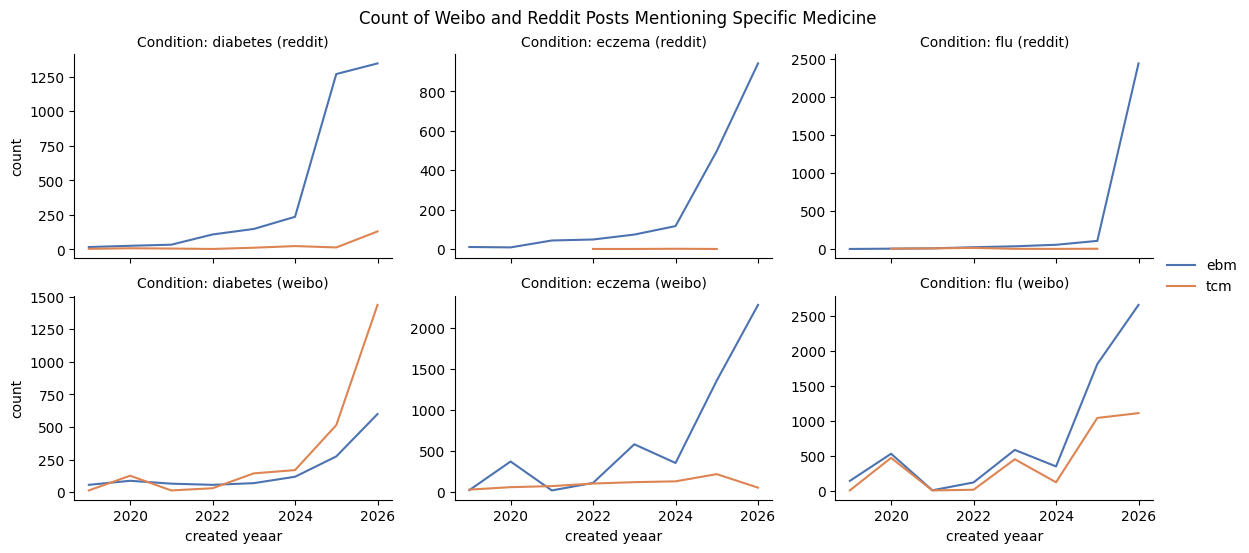

In [38]:
agg_df = sent_df.groupby(by=['source', 'medicine_category', 'medicine_type', 'created_year'])['id'].agg('count').to_frame().reset_index()
agg_df = agg_df.rename(columns={'id': 'count'})
g = sns.FacetGrid(agg_df, row = "source", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
med_types = agg_df["medicine_type"].unique().tolist()
med_types.sort()
g.map_dataframe(sns.lineplot, x="created_year", y='count', hue="medicine_type", hue_order=med_types, palette="deep")
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Count of Weibo and Reddit Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.set_xlabels("created yeaar")
g.add_legend()
g.savefig("results/absa_count.png", dpi=310)

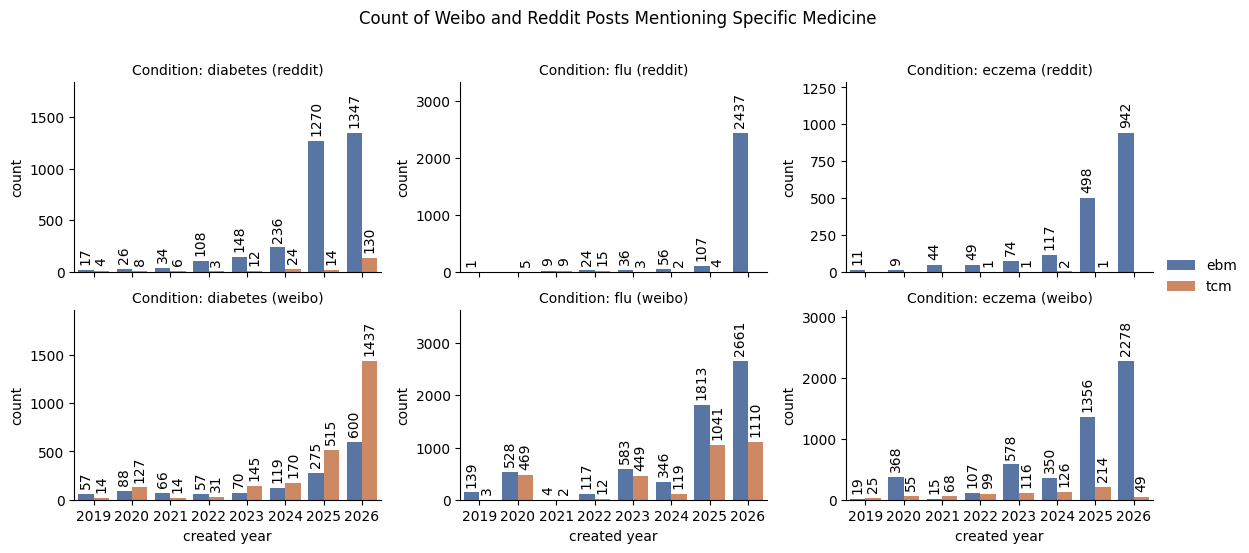

In [39]:
g = sns.FacetGrid(sent_df, row = "source", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
def custom_countplot(**kwargs):
    ax = sns.countplot(**kwargs)
    for container in ax.containers:
        ax.bar_label(container, rotation=90, padding=4)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.3)
med_types = sent_df["medicine_type"].unique().tolist()
med_types.sort()
g.map_dataframe(custom_countplot, x="created_year", hue="medicine_type", hue_order=med_types, palette="deep", dodge=True)
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Count of Weibo and Reddit Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.set_xlabels("created year")
g.add_legend()
g.savefig("results/absa_count_labeled.png", dpi=310)

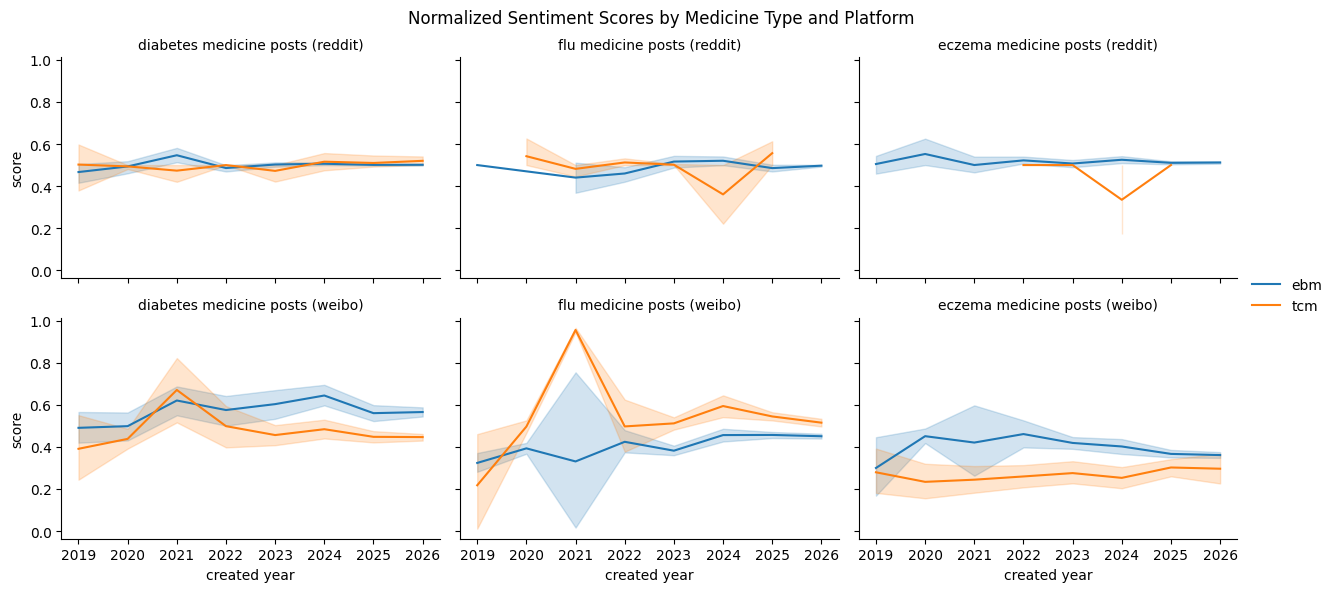

In [40]:
g = sns.FacetGrid(sent_df, row='source', col='medicine_category', height=3, aspect=1.4)
med_types = sent_df["medicine_type"].unique().tolist()
med_types.sort()
g.map_dataframe(sns.lineplot, x='created_year', y='score', hue='medicine_type', hue_order=med_types)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("created year")
g.fig.suptitle("Normalized Sentiment Scores by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_scores.png", dpi=310)

### Categorize

In [41]:
def categorize_df(df, groupby_cols):
    pos_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Positive')).to_frame().reset_index().rename(columns = {"sentiment": "positive_count"})
    neg_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Negative')).to_frame().reset_index().rename(columns = {"sentiment": "negative_count"})
    count_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg('count').to_frame().reset_index().rename(columns = {"sentiment": "count"})
    category_df = pd.merge(pos_df, neg_df, on=groupby_cols, how='inner')
    category_df = pd.merge(category_df, count_df, on=groupby_cols, how='inner')
    return category_df

In [42]:
groupby_cols = ['source', 'medicine_category', 'medicine_type', 'created_year']
category_df = categorize_df(sent_df, groupby_cols)
category_df

,source,medicine_category,medicine_type,created_year,positive_count,negative_count,count
0,reddit,diabetes,ebm,2019,2,3,17
1,reddit,diabetes,ebm,2020,1,1,26
2,reddit,diabetes,ebm,2021,10,2,34
3,reddit,diabetes,ebm,2022,6,11,108
4,reddit,diabetes,ebm,2023,14,16,148
...,...,...,...,...,...,...,...
84,weibo,flu,tcm,2022,2,2,12
85,weibo,flu,tcm,2023,165,147,449
86,weibo,flu,tcm,2024,56,24,119
87,weibo,flu,tcm,2025,438,307,1041


In [43]:
category_df['positive'] = category_df['positive_count'] / category_df['count'] * 100
category_df['negative'] = category_df['negative_count'] / category_df['count'] * 100

In [44]:
category_df_long = category_df.melt(
    id_vars = groupby_cols,
    value_vars = ['positive', 'negative'],
    value_name = 'percent',
    var_name = 'sentiment'
)
category_df_long

,source,medicine_category,medicine_type,created_year,sentiment,percent
0,reddit,diabetes,ebm,2019,positive,11.764706
1,reddit,diabetes,ebm,2020,positive,3.846154
2,reddit,diabetes,ebm,2021,positive,29.411765
3,reddit,diabetes,ebm,2022,positive,5.555556
4,reddit,diabetes,ebm,2023,positive,9.459459
...,...,...,...,...,...,...
173,weibo,flu,tcm,2022,negative,16.666667
174,weibo,flu,tcm,2023,negative,32.739421
175,weibo,flu,tcm,2024,negative,20.168067
176,weibo,flu,tcm,2025,negative,29.490874


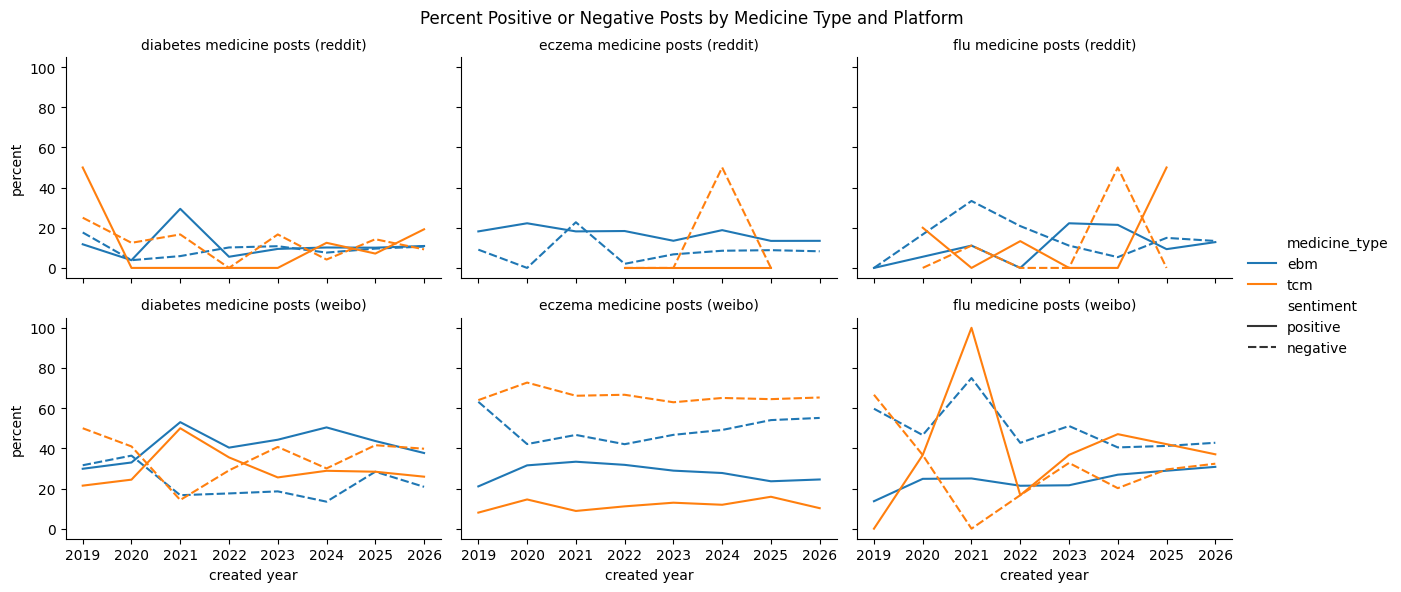

In [45]:
g = sns.FacetGrid(category_df_long, row='source', col='medicine_category', height=3, aspect=1.4)
med_types = category_df_long["medicine_type"].unique().tolist()
med_types.sort()
sent_types = ['positive', 'negative']
g.map_dataframe(
    sns.lineplot, x='created_year', y='percent',
    hue='medicine_type', hue_order=med_types,
    style='sentiment', style_order=sent_types
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("created year")
g.fig.suptitle("Percent Positive or Negative Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_categories.png", dpi=310)

In [80]:
COVID_CUTOFF = 2023
sent_df = pd.read_csv("corpus/metadata_with_absa_scores.csv")

In [81]:
sent_df['period'] = (sent_df['created_year'] > COVID_CUTOFF).apply(lambda x: "post-covid" if x else "covid")

In [82]:
covid_sent_df = categorize_df(sent_df, groupby_cols = ['source', 'medicine_category', 'medicine_type', 'period'])
covid_sent_df

,source,medicine_category,medicine_type,period,positive_count,negative_count,count
0,reddit,diabetes,ebm,covid,33,33,333
1,reddit,diabetes,ebm,post-covid,299,283,2853
2,reddit,diabetes,tcm,covid,2,5,33
3,reddit,diabetes,tcm,post-covid,29,15,168
4,reddit,eczema,ebm,covid,31,17,187
5,reddit,eczema,ebm,post-covid,216,132,1557
6,reddit,eczema,tcm,covid,0,0,2
7,reddit,eczema,tcm,post-covid,0,1,3
8,reddit,flu,ebm,covid,9,12,70
9,reddit,flu,ebm,post-covid,335,346,2600


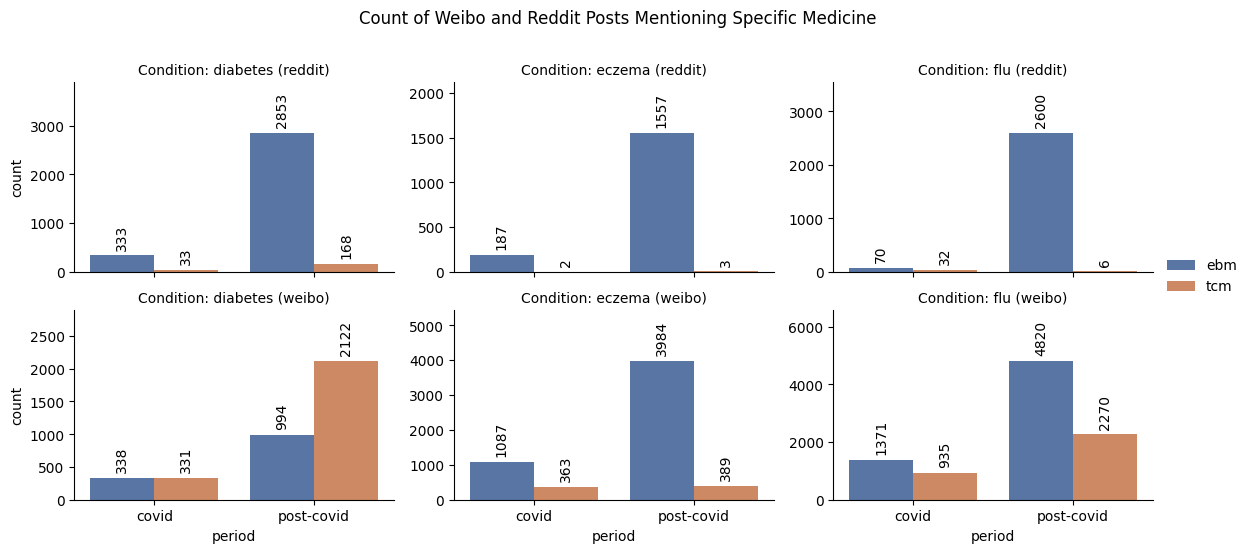

In [85]:
g = sns.FacetGrid(covid_sent_df, row = "source", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
def custom_barplot(**kwargs):
    ax = sns.barplot(**kwargs)
    for container in ax.containers:
        ax.bar_label(container, rotation=90, padding=4)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.3)
med_types = covid_sent_df["medicine_type"].unique().tolist()
med_types.sort()
g.map_dataframe(custom_barplot, x="period", y='count', hue="medicine_type", hue_order=med_types, palette="deep", dodge=True)
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Count of Weibo and Reddit Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.add_legend()
g.savefig("results/absa_count_labeled_by_period.png", dpi=310)

In [74]:
covid_sent_df['positive'] = covid_sent_df['positive_count'] / covid_sent_df['count'] * 100
covid_sent_df['negative'] = covid_sent_df['negative_count'] / covid_sent_df['count'] * 100

In [75]:
covid_sent_df_long = covid_sent_df.melt(
    id_vars = ['source', 'medicine_category', 'medicine_type', 'period'],
    value_vars = ['positive', 'negative'],
    value_name = 'percent',
    var_name = 'sentiment'
)
covid_sent_df_long.head(2)

,source,medicine_category,medicine_type,period,sentiment,percent
0,reddit,diabetes,ebm,covid,positive,9.909910
1,reddit,diabetes,ebm,post-covid,positive,10.480196


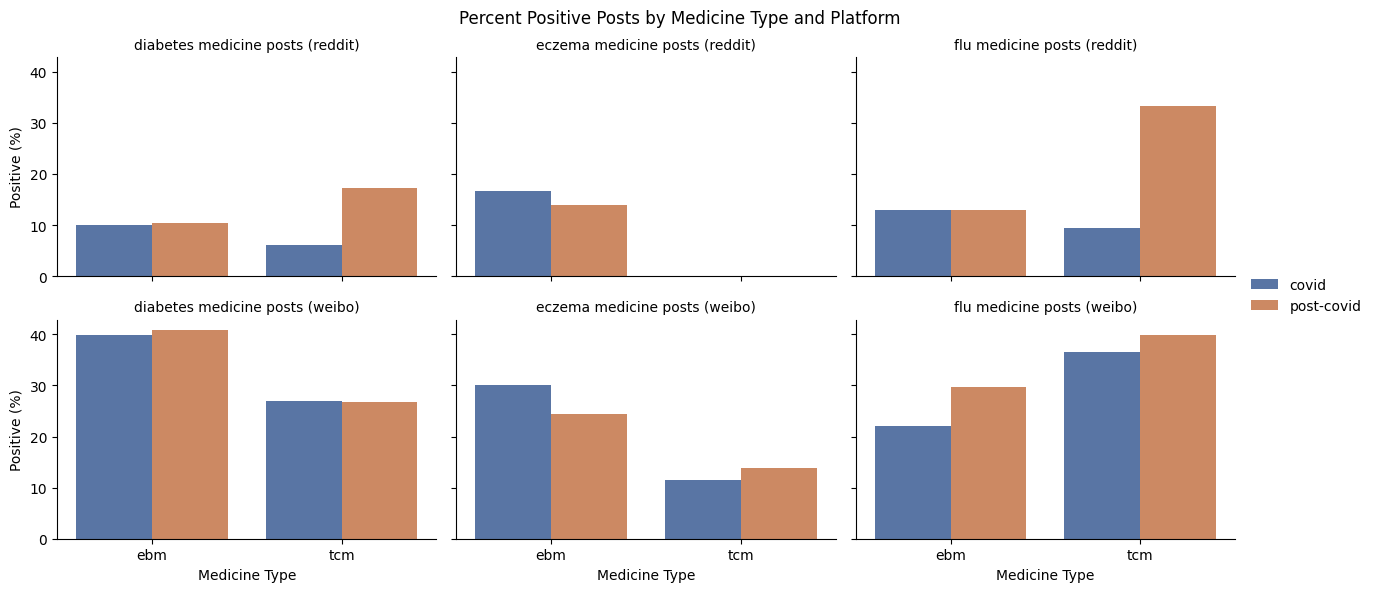

In [77]:
g = sns.FacetGrid(covid_sent_df, row='source', col='medicine_category', height=3, aspect=1.4)
g.map_dataframe(
    sns.barplot, x='medicine_type', y='positive',
    hue='period', hue_order=["covid", "post-covid"],
    palette='deep'
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("Medicine Type")
g.set_ylabels("Positive (%)")
g.fig.suptitle("Percent Positive Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_covid_positives.png", dpi=310)

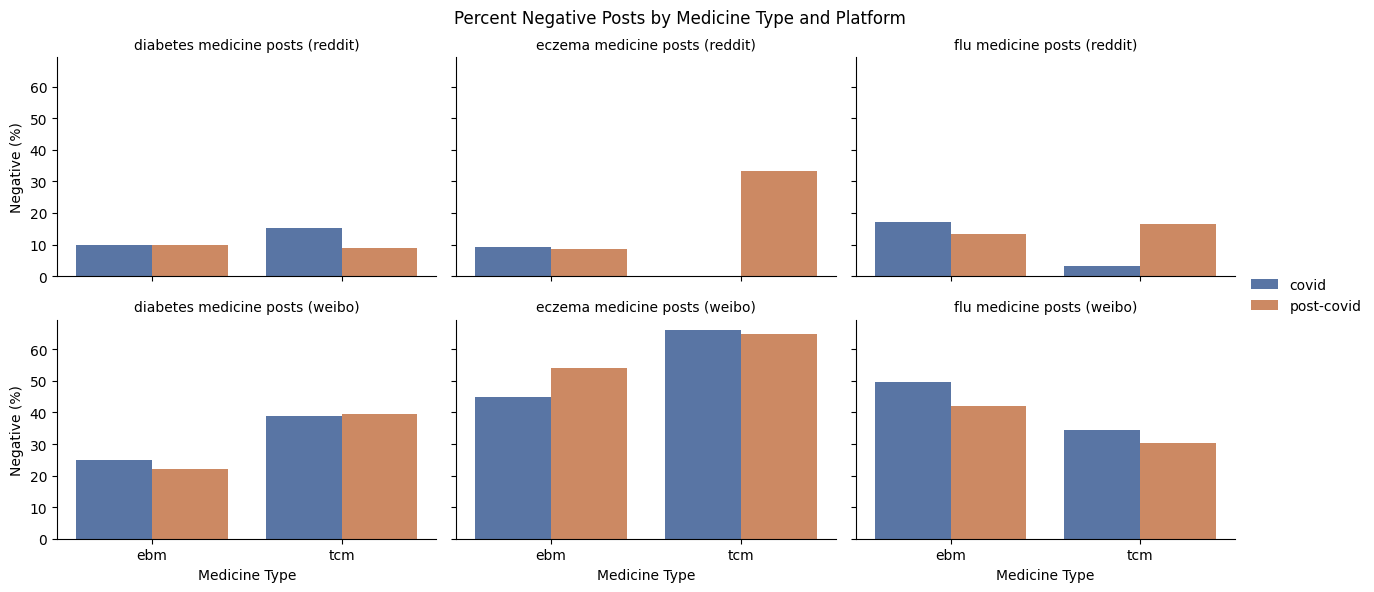

In [78]:
g = sns.FacetGrid(covid_sent_df, row='source', col='medicine_category', height=3, aspect=1.4)
g.map_dataframe(
    sns.barplot, x='medicine_type', y='negative',
    hue='period', hue_order=["covid", "post-covid"],
    palette='deep'
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("Medicine Type")
g.set_ylabels("Negative (%)")
g.fig.suptitle("Percent Negative Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_covid_negatives.png", dpi=310)

### Is there a difference between COVID and post-COVID opinions on the same types of medicines?

In [53]:
covid_sent_df.head(2)

,source,medicine_category,medicine_type,period,positive_count,negative_count,count,positive,negative
0,reddit,diabetes,ebm,covid,33,33,333,9.909910,9.909910
1,reddit,diabetes,ebm,post-covid,299,283,2853,10.480196,9.919383


In [54]:
conds = covid_sent_df[['source', 'medicine_category', 'medicine_type']].drop_duplicates()
pvals = []
zstats = []
for i, series in conds.iterrows():
    source, med_cat, med_type = series
    df = covid_sent_df.query("source==@source and medicine_category==@med_cat and medicine_type==@med_type")
    successes = (df[df['period']=='covid']['positive_count'].iloc[0], df[df['period']=='post-covid']['positive_count'].iloc[0])
    counts = (df[df['period']=='covid']['count'].iloc[0], df[df['period']=='post-covid']['count'].iloc[0])
    stat, pval = proportions_ztest(successes, counts, alternative="two-sided")
    zstats.append(stat)
    pvals.append(pval)

/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


positive z values: covid > post-covid

In [55]:
conds['pval_two_sided'] = pvals
conds['z_stat_two_sided'] = zstats
conds['sig_two_sided'] = conds['pval_two_sided'] < (ALPHA/conds.shape[0])
conds

,source,medicine_category,medicine_type,pval_two_sided,z_stat_two_sided,sig_two_sided
0,reddit,diabetes,ebm,7.472071e-01,-0.322324,False
2,reddit,diabetes,tcm,1.033514e-01,-1.628819,False
4,reddit,eczema,ebm,3.161970e-01,1.002304,False
6,reddit,eczema,tcm,NaN,NaN,False
8,reddit,flu,ebm,9.945981e-01,-0.006770,False
10,reddit,flu,tcm,1.111262e-01,-1.593151,False
12,weibo,diabetes,ebm,7.699684e-01,-0.292416,False
14,weibo,diabetes,tcm,9.487461e-01,0.064282,False
16,weibo,eczema,ebm,2.223135e-04,3.692210,True
18,weibo,eczema,tcm,3.425348e-01,-0.949169,False


In [56]:
conds.to_csv("results/absa_longitudinal_trust_change_stats.csv", index=False)

### Is there a difference between post-COVID opinions on EBM vs. TCM?

In [57]:
post_covid = covid_sent_df[covid_sent_df['period']=="post-covid"]
conds = post_covid[['source', 'medicine_category']].drop_duplicates()
pvals = []
zstats = []
for i, series in conds.iterrows():
    source, med_cat = series
    df = post_covid.query("source==@source and medicine_category==@med_cat")
    successes = (df[df['medicine_type']=='tcm']['positive_count'].iloc[0], df[df['medicine_type']=='ebm']['positive_count'].iloc[0])
    counts = (df[df['medicine_type']=='tcm']['count'].iloc[0], df[df['medicine_type']=='ebm']['count'].iloc[0])
    stat, pval = proportions_ztest(successes, counts, alternative="two-sided")
    zstats.append(stat)
    pvals.append(pval)

Positive z values: tcm > ebm

In [58]:
conds['pval_two_sided'] = pvals
conds['z_stat_two_sided'] = zstats
conds['sig_two_sided'] = conds['pval_two_sided'] < (ALPHA/conds.shape[0])
conds

,source,medicine_category,pval_two_sided,z_stat_two_sided,sig_two_sided
1,reddit,diabetes,6.036819e-03,2.745775,True
5,reddit,eczema,4.870342e-01,-0.695034,False
9,reddit,flu,1.359563e-01,1.491020,False
13,weibo,diabetes,2.187526e-15,-7.930223,True
17,weibo,eczema,2.597705e-06,-4.700307,True
21,weibo,flu,3.327714e-17,8.434447,True


In [59]:
conds.to_csv("results/absa_tcm_vs_ebm_postcovid_stats.csv", index=False)

### Is there a difference between post-COVID opinion polarization on Weibo vs. Reddit?

#### Is the ratio of (positive TCM / positive EBM) different between platforms?

In [60]:
post_covid = covid_sent_df[covid_sent_df['period']=="post-covid"]
conds = post_covid[['medicine_category']].drop_duplicates()
pvals = []
print(f"Significance level = {ALPHA / conds.shape[0]}")
for i, series in conds.iterrows():
    med_cat = series['medicine_category']
    df = post_covid.query("medicine_category==@med_cat")
    weibo = df[df['source'] == 'weibo']
    reddit = df[df['source'] == 'reddit']
    contingency_table = [
        [weibo[weibo['medicine_type']=='tcm']['positive_count'].iloc[0], weibo[weibo['medicine_type']=='ebm']['positive_count'].iloc[0]], # Weibo Positive Posts
        [reddit[reddit['medicine_type']=='tcm']['positive_count'].iloc[0], reddit[reddit['medicine_type']=='ebm']['positive_count'].iloc[0]]  # Reddit Positive Posts
    ]
    chi2, pval, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"<======== {med_cat} | p-value: {np.round(pval, 4)} | sig = {pval < ALPHA / conds.shape[0]} ========>")
    print(pd.DataFrame(contingency_table, index=['weibo', 'reddit'], columns=['tcm', 'ebm']))
    print(pd.DataFrame(np.round(expected).astype(int), index=['weibo', 'reddit'], columns=['tcm', 'ebm']))
    pvals.append(pval)

Significance level = 0.016666666666666666
<======== diabetes | p-value: 0.0 | sig = True ========>
        tcm  ebm
weibo   567  406
reddit   29  299
        tcm  ebm
weibo   446  527
reddit  150  178
<======== eczema | p-value: 0.0011 | sig = True ========>
        tcm  ebm
weibo    54  975
reddit    0  216
        tcm  ebm
weibo    45  984
reddit    9  207
<======== flu | p-value: 0.0 | sig = True ========>
        tcm   ebm
weibo   905  1435
reddit    2   335
        tcm   ebm
weibo   793  1547
reddit  114   223


#### Is the difference in post-COVID trust in TCM vs. EBM different by platform?

In [61]:
COVID_CUTOFF = 2023
sent_df = pd.read_csv("corpus/metadata_with_absa_scores.csv")
sent_df['period'] = (sent_df['created_year'] > COVID_CUTOFF).apply(lambda x: "post-covid" if x else "covid")
post_covid_sent = sent_df[sent_df['period'] == 'post-covid']
post_covid_sent = post_covid_sent[['id', 'sentiment', 'source', 'medicine_category', 'medicine_type']]
post_covid_sent.head(2)

,id,sentiment,source,medicine_category,medicine_type
0,34344,Neutral,reddit,diabetes,ebm
1,32408,Positive,reddit,flu,ebm


In [62]:
def calc_proportions(df, groupby_cols):
    pos_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Positive')).to_frame().reset_index().rename(columns = {"sentiment": "positive_count"})
    neg_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Negative')).to_frame().reset_index().rename(columns = {"sentiment": "negative_count"})
    count_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg('count').to_frame().reset_index().rename(columns = {"sentiment": "count"})
    category_df = pd.merge(pos_df, neg_df, on=groupby_cols, how='inner')
    category_df = pd.merge(category_df, count_df, on=groupby_cols, how='inner')
    category_df['pos_p'] = category_df['positive_count'] / category_df['count']
    category_df['neg_p'] = category_df['negative_count'] / category_df['count']
    return category_df

In [63]:
def calc_pos_p_diff(metadata):
    groupby_cols = ['source', 'medicine_category', 'medicine_type']
    df = calc_proportions(metadata, groupby_cols=groupby_cols)
    df = df.pivot_table(index=['source', 'medicine_category'], columns='medicine_type', values='pos_p').reset_index()
    df['tcm-ebm'] = df['tcm'] - df['ebm']
    return df[['source', 'medicine_category', 'tcm-ebm']]

In [64]:
def calc_did(metadata):
    df = calc_pos_p_diff(metadata)
    df = df.pivot_table(index='medicine_category', columns='source', values='tcm-ebm').reset_index()
    df['weibo-reddit_tcm-ebm'] = df['weibo'] - df['reddit']
    return df

In [65]:
emp_df = calc_did(post_covid_sent)
emp_df

source,medicine_category,reddit,weibo,weibo-reddit_tcm-ebm
0,diabetes,0.067817,-0.141250,-0.209067
1,eczema,-0.138728,-0.105911,0.032817
2,flu,0.204487,0.100961,-0.103527


In [66]:
n_permutes = 999
rng = np.random.default_rng(42)
emp_df = calc_did(post_covid_sent)
for i in tqdm(range(n_permutes)):
    permuted_md = post_covid_sent.copy()
    permuted_md['source'] = post_covid_sent['source'].sample(
        n=len(post_covid_sent['source']), replace=False, random_state = rng
    ).to_list()
    null_df = calc_did(permuted_md)[['medicine_category', 'weibo-reddit_tcm-ebm']]
    null_df = null_df.rename(columns = {'weibo-reddit_tcm-ebm': f'null_{i}'})
    emp_df = pd.merge(emp_df, null_df, on='medicine_category')

  0%|          | 0/999 [00:00<?, ?it/s]

In [67]:
p_vals = []
null_means = []
null_stds = []
for i, series in emp_df.iterrows():
    emp_dp = series['weibo-reddit_tcm-ebm']
    null_dps = series[[f"null_{i}" for i in range(n_permutes)]]
    n_ge = sum(abs(null_dps) >= abs(emp_dp))
    p_val = (n_ge+1)/(n_permutes+1)
    null_mean = null_dps.mean()
    null_std = null_dps.std()
    p_vals.append(p_val)
    null_means.append(null_mean)
    null_stds.append(null_std)

In [68]:
dp_df = emp_df[['medicine_category', 'weibo-reddit_tcm-ebm']].copy()
dp_df['p_val'] = p_vals
dp_df['null_mean'] = null_means
dp_df['null_std'] = null_stds
dp_df

source,medicine_category,weibo-reddit_tcm-ebm,p_val,null_mean,null_std
0,diabetes,-0.209067,0.001,0.000547,0.024075
1,eczema,0.032817,0.412,-0.003322,0.038752
2,flu,-0.103527,0.001,0.000182,0.024454


In [69]:
dp_df.to_csv("results/absa_did_by_med_category.csv", index=False)

# ML Classifier

### Manually annotate training set

I used the following code to randomly sample entries to annotate. However, after annotation was finished, I made a change to the workflow that re-ordered the dataframe. Therefore, running the following code will not reproduce the training set. I will still use the old annotated set in training.

***The following is run on Google Colab GPU***<br>
***Note the relative paths reflect those in Google Drive, not the local paths***

In [4]:
parsed_df = pd.read_parquet('parsed_cleaned_posts.parquet')
med_df = pd.read_csv("source_and_cleanup_metadata.csv")
parsed_df = parsed_df.merge(med_df[['id', 'source']], on='id')
annot = pd.read_csv("annot_categorized.csv")
annot = annot[['id', 'trust']].merge(parsed_df, on='id', how='inner')
annot.shape

(637, 9)

In [5]:
annot.head(1)

,id,trust,note_id,medicine_name,title_language,content_language,title_parsed,content_parsed,source
0,31790,1,bf52fb30732784c147e005540d305e01300598cfb63616...,Advil,en,en,[],[n't needed any more serious painkillers besid...,reddit


## Training

[XLM-RoBERTa](https://huggingface.co/docs/transformers/model_doc/xlm-roberta)

In [6]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [59]:
tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-large"
)
roberta = AutoModel.from_pretrained("xlm-roberta-base")
special_tokens = tokenizer.special_tokens_map
print(tokenizer.special_tokens_map)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


In [4]:
def format_prompt(series):
    sep = f"{special_tokens['sep_token']} {special_tokens['sep_token']}"
    text = np.concatenate((series['title_parsed'], series['content_parsed']), axis=0)
    text_joined = sep.join(text)
    prompt = f"{series['medicine_name']} {sep} {text_joined}"
    return prompt

In [ ]:
annot['prompt'] = annot.apply(format_prompt, axis=1)

**Test**

In [65]:
inputs = tokenizer(
    annot['prompt'].iloc[0], padding="longest",
    truncation=True,
    max_length=512,
    return_tensors="pt"
).to(device)
tokenizer.decode(inputs['input_ids'])

["<s> Advil</s></s> n't needed any more serious painkillers besides Tylenol and Advil</s>"]

In [66]:
roberta = roberta.to(device)
with torch.no_grad():
    encodings_d = roberta(**inputs)

In [67]:
encodings_d.pooler_output.shape

torch.Size([1, 768])

***Training***

In [5]:
class PostSet(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        series = self.df.iloc[idx]
        return series['prompt'], int(series['trust'])+1

In [6]:
class RobertaMLPClassifier(nn.Module):
    def __init__(self, roberta, embedding_dim, output_classes, dropout=0.5):
        super().__init__()
        self.transformer = roberta
        self.cls = nn.Sequential(
            nn.Dropout(p = dropout),
            nn.Linear(embedding_dim, output_classes)
        )

    def forward(self, tokenized_x):
        encodings = self.transformer(**tokenized_x).last_hidden_state
        pooled = torch.mean(encodings, axis=1)
        logits = self.cls(pooled)
        return logits
  
    def predict_proba(self, tokenized_x):
        logits = self.forward(tokenized_x)
        proba = F.softmax(logits, dim=1)
        return proba

In [62]:
a = sum(annot['trust']==-1); b = sum(annot['trust']==0); c = sum(annot['trust']==1)
a, b, c

(53, 378, 206)

In [63]:
model = RobertaMLPClassifier(roberta, 768, 3).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
class_weights = torch.tensor([b*c, a*c, a*b], dtype=torch.float32).to(device)
def run_epoch(loader, model=model, tokenizer=tokenizer, class_weights=class_weights, train=True):
    if train:
        model.train()
    else:
        model.eval()
    correct = 0
    total = 0
    losses = []
    for prompts, ys in loader:
        y_d = ys.to(device)
        tokens_d = tokenizer(
            prompts,
            padding="longest",
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)
        logits_d = model(tokens_d)
        loss = F.cross_entropy(logits_d, y_d, weight=class_weights)
        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()
        pred = logits_d.argmax(dim=1)
        correct += (pred == y_d).sum().item()
        total += ys.size(0)
        losses.append(loss.item())
    return np.mean(losses), correct / max(total, 1)

In [64]:
torch.cuda.empty_cache()

epochs = 50
patience = 7
patience_counter = 0
batch_size = 64
best_loss = float('inf')
pbar = tqdm(total=epochs)

np.random.seed(42)
length = annot.shape[0]
train_idx = list(annot.sample(round(length*0.8)).index)
test_idx = list(set(range(length)) - set(train_idx))
train_ds = PostSet(annot.iloc[train_idx])
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_ds = PostSet(annot.iloc[test_idx])
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=True)

for ep in range(epochs):    
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    te_loss, te_acc = run_epoch(test_loader, train=False)
    
    if te_loss < best_loss:
        best_loss = te_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_trust_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {ep+1}. Restoring best model.")
            model.load_state_dict(torch.load('best_trust_model.pt'))
            break
    pbar.update(1)
    pbar.set_description(f"epoch {ep+1:02d} summary: train_loss={tr_loss:.2f}, train_acc={tr_acc:.2f}, test_acc={te_acc:.2f}")
pbar.close()

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping triggered at epoch 22. Restoring best model.


In [ ]:
probas = []
y = []
with torch.no_grad():
    for prompts, ys in test_loader:
        y_d = ys.to(device)
        tokens_d = tokenizer(
            prompts,
            padding="longest",
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)
        proba = model.predict_proba(tokens_d)
        y.append(ys)
        probas.append(proba.to('cpu'))

In [80]:
probas = torch.concat(probas, axis=0)
y = np.concatenate(y, axis=0)

In [81]:
preds = torch.argmax(probas, axis=1)

In [84]:
print(precision_score(y, preds, average='macro'))
print(recall_score(y, preds, average='macro'))
print(accuracy_score(y, preds))
print(f1_score(y, preds, average='macro'))
print(roc_auc_score(y, probas, average='macro', multi_class='ovo'))

0.6404390816155522
0.7544019429265331
0.6614173228346457
0.6346537842190015
0.9006358362004993


In [97]:
counts = np.array([53, 378, 206])
priors = counts / counts.sum()
adjusted_probas = probas * priors
adjusted_probas /= torch.sum(adjusted_probas, axis=1).unsqueeze(1)
adjusted_preds = torch.argmax(adjusted_probas, axis=1)

/tmp/ipykernel_12462/4191473608.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  adjusted_probas = probas * priors


In [98]:
print(precision_score(y, adjusted_preds, average='macro'))
print(recall_score(y, adjusted_preds, average='macro'))
print(accuracy_score(y, adjusted_preds))
print(f1_score(y, adjusted_preds, average='macro'))
print(roc_auc_score(y, adjusted_probas, average='macro', multi_class='ovo'))

0.6917435221783048
0.7848107670512042
0.7322834645669292
0.7081035923141187
0.9096421102340956


### Retrain on the entire test set

In [101]:
# flush weights
tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-large"
)
roberta = AutoModel.from_pretrained("xlm-roberta-base")
model = RobertaMLPClassifier(roberta, 768, 3).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
class_weights = torch.tensor([b*c, a*c, a*b], dtype=torch.float32).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [102]:
torch.cuda.empty_cache()

epochs = 22 - 7 # This was the training epoch with the peak accuracy!
batch_size = 64
pbar = tqdm(total=epochs)

np.random.seed(42)
train_ds = PostSet(annot)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

acc = []

for ep in range(epochs):
    tr_loss, tr_acc = run_epoch(train_loader, model=model, tokenizer=tokenizer, train=True)
    pbar.update(1)
    acc.append(tr_acc)
    pbar.set_description(f"epoch {ep+1:02d} summary: train_loss={tr_loss:.2f}, train_acc={tr_acc:.2f}")
pbar.close()

  0%|          | 0/15 [00:00<?, ?it/s]

In [103]:
torch.save(model.state_dict(), 'deployed_trust_model.pt')

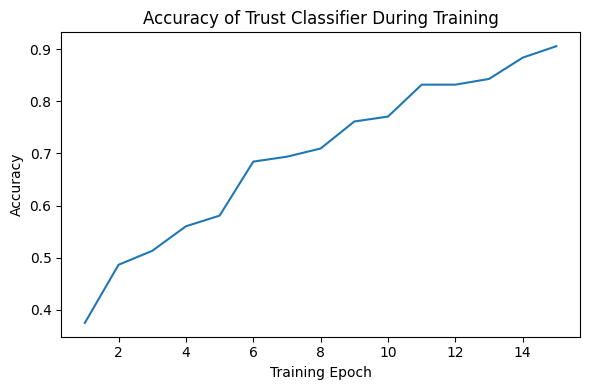

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(epochs)+1, acc)
ax.set_title("Accuracy of Trust Classifier During Training")
ax.set_xlabel("Training Epoch")
ax.set_ylabel("Accuracy")
plt.tight_layout()
fig.savefig("trust_classifier_training.png", dpi=300)

## Classification

***Still performed in Google Colab!***

In [10]:
tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-large"
)
roberta = AutoModel.from_pretrained("xlm-roberta-base")
special_tokens = tokenizer.special_tokens_map
model = RobertaMLPClassifier(roberta, 768, 3).to(device)
model.load_state_dict(torch.load('deployed_trust_model.pt'))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [12]:
parsed_df = pd.read_parquet('parsed_cleaned_posts.parquet')
med_df = pd.read_csv("source_and_cleanup_metadata.csv")
parsed_df = parsed_df.merge(med_df[['id', 'source']], on='id')
annot = pd.read_csv("annot_categorized.csv")
unannot_id = list(set(parsed_df['id'].to_list()) - set(annot['id'].to_list()))
unannot = parsed_df.query('id in @unannot_id').copy()
unannot.shape

(26211, 8)

In [13]:
unannot['prompt'] = unannot.apply(format_prompt, axis=1)
unannot['trust'] = 0 # placeholder!

In [16]:
unannot_set = PostSet(unannot)
batch_size = 64
unannot_loader = DataLoader(unannot_set, batch_size=batch_size, shuffle=False)
probas = []
with torch.no_grad():
    for prompts, _ in tqdm(unannot_loader):
        tokens_d = tokenizer(
            prompts,
            padding="longest",
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)
        proba = model.predict_proba(tokens_d)
        probas.append(proba.to('cpu'))

  0%|          | 0/410 [00:00<?, ?it/s]

In [17]:
probas_c = torch.concat(probas, axis=0)
counts = np.array([53, 378, 206])
priors = counts / counts.sum()
adjusted_probas = probas_c * priors
adjusted_probas /= torch.sum(adjusted_probas, axis=1).unsqueeze(1)
adjusted_preds = torch.argmax(adjusted_probas, axis=1)

/tmp/ipykernel_35463/1692491027.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  adjusted_probas = probas_c * priors


In [18]:
unannot['distrust_proba'] = adjusted_probas[:, 0]
unannot['neutral_proba'] = adjusted_probas[:, 1]
unannot['trust_proba'] = adjusted_probas[:, 2]
unannot['trust'] = adjusted_preds - 1

In [19]:
unannot[['id', 'distrust_proba', 'neutral_proba', 'trust_proba', 'trust']].to_csv("unannot_predicted.csv", index=False)

***Back to local Python kernel***

In [3]:
parsed_df = pd.read_parquet('corpus/absa/parsed_cleaned_posts.parquet')
med_df = pd.read_csv("corpus/source_and_cleanup_metadata.csv")
parsed_df = parsed_df.merge(med_df[['id', 'source']], on='id')

In [8]:
unannot = pd.read_csv("results/ml/unannot_predicted.csv")[['id', 'trust']]
annot = pd.read_csv("results/ml/annot_categorized.csv")[['id', 'trust']]
samples = list(set(parsed_df['id'].to_list()) & set(annot['id'].to_list()))
annot = annot.query("id in @samples")
combined = pd.concat([unannot, annot], axis=0)

In [10]:
combined.to_csv("results/ml/combined_annot.csv", index=False)

## Result

### Merge sentiment scores

In [13]:
trust = pd.read_csv("results/ml/combined_annot.csv")
trust['trust'] = trust['trust'].apply(lambda x: ["Neutral", "Trust", "Distrust"][x])
trust.head(2)

,id,trust
0,34344,Neutral
1,15129,Neutral


In [15]:
metadata = pd.read_csv("corpus/metadata_with_absa_scores.csv")

In [16]:
trust = pd.merge(trust, metadata, on='id', how='left')
trust.head(2)

,id,trust,score,sentiment,ups,note_id,downs,search_keyword,poster,created_year,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
0,34344,Neutral,0.500000,Neutral,37,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,0.0,Tresiba,2e65009b7023d6202cf0322ea037e3f9dccbad95d3d21a...,2025,...,Insulin,diabetes,ebm,False,en,0.972991,en,0.831891,True,1.0
1,15129,Neutral,0.368899,Neutral,1,d54273d76a9e58747c68f71e4416741a424e96fe835df5...,NaN,泰诺,ee3fb8546089cd65768e97fd7e37c69d9c34a25cae634d...,2026,...,Acetaminophen,flu,ebm,False,zh,0.989413,NaN,NaN,True,1.0


In [17]:
trust.to_csv("corpus/metadata_with_absa_scores_and_trust.csv", index=False)

### Categorize

In [19]:
def categorize_df(df, groupby_cols):
    pos_df = df.groupby(
        by=groupby_cols
    )['trust'].agg(lambda x: sum(x=='Trust')).to_frame().reset_index().rename(columns = {"trust": "trust_count"})
    neg_df = df.groupby(
        by=groupby_cols
    )['trust'].agg(lambda x: sum(x=='Distrust')).to_frame().reset_index().rename(columns = {"trust": "distrust_count"})
    count_df = df.groupby(
        by=groupby_cols
    )['trust'].agg('count').to_frame().reset_index().rename(columns = {"trust": "count"})
    category_df = pd.merge(pos_df, neg_df, on=groupby_cols, how='inner')
    category_df = pd.merge(category_df, count_df, on=groupby_cols, how='inner')
    return category_df

In [20]:
groupby_cols = ['source', 'medicine_category', 'medicine_type', 'created_year']
category_df = categorize_df(trust, groupby_cols)
category_df

,source,medicine_category,medicine_type,created_year,trust_count,distrust_count,count
0,reddit,diabetes,ebm,2019,0,0,17
1,reddit,diabetes,ebm,2020,1,4,26
2,reddit,diabetes,ebm,2021,4,4,34
3,reddit,diabetes,ebm,2022,4,5,108
4,reddit,diabetes,ebm,2023,8,8,148
...,...,...,...,...,...,...,...
84,weibo,flu,tcm,2022,5,0,12
85,weibo,flu,tcm,2023,219,36,449
86,weibo,flu,tcm,2024,69,7,119
87,weibo,flu,tcm,2025,653,61,1041


In [22]:
category_df['trust'] = category_df['trust_count'] / category_df['count'] * 100
category_df['distrust'] = category_df['distrust_count'] / category_df['count'] * 100

In [23]:
category_df_long = category_df.melt(
    id_vars = groupby_cols,
    value_vars = ['trust', 'distrust'],
    value_name = 'percent',
    var_name = 'trust'
)
category_df_long

,source,medicine_category,medicine_type,created_year,trust,percent
0,reddit,diabetes,ebm,2019,trust,0.000000
1,reddit,diabetes,ebm,2020,trust,3.846154
2,reddit,diabetes,ebm,2021,trust,11.764706
3,reddit,diabetes,ebm,2022,trust,3.703704
4,reddit,diabetes,ebm,2023,trust,5.405405
...,...,...,...,...,...,...
173,weibo,flu,tcm,2022,distrust,0.000000
174,weibo,flu,tcm,2023,distrust,8.017817
175,weibo,flu,tcm,2024,distrust,5.882353
176,weibo,flu,tcm,2025,distrust,5.859750


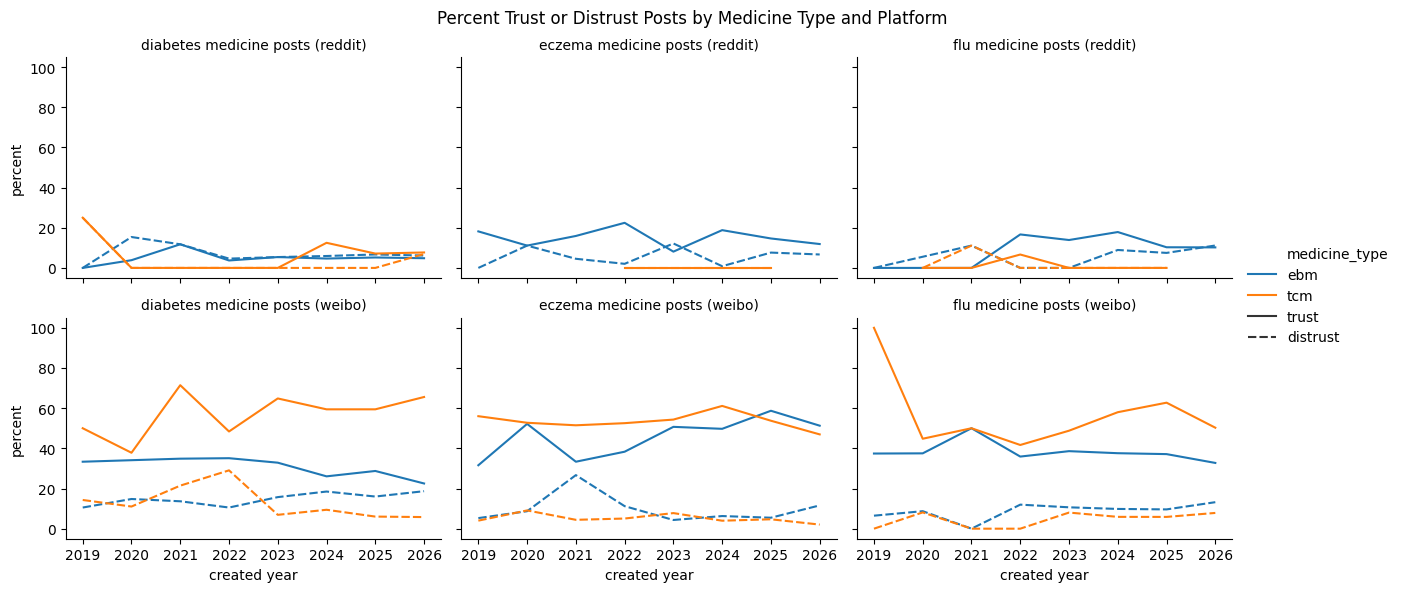

In [ ]:
g = sns.FacetGrid(category_df_long, row='source', col='medicine_category', height=3, aspect=1.4)
med_types = category_df_long["medicine_type"].unique().tolist()
med_types.sort()
trust_types = ['trust', 'distrust']
g.map_dataframe(
    sns.lineplot, x='created_year', y='percent',
    hue='medicine_type', hue_order=med_types,
    style='trust', style_order=trust_types
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("created year")
g.fig.suptitle("Percent Trust or Distrust Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/ml/trust_categories.png", dpi=310)

In [25]:
COVID_CUTOFF = 2023
trust = pd.read_csv("corpus/metadata_with_absa_scores_and_trust.csv")

In [26]:
trust['period'] = (trust['created_year'] > COVID_CUTOFF).apply(lambda x: "post-covid" if x else "covid")

In [27]:
covid_trust_df = categorize_df(trust, groupby_cols = ['source', 'medicine_category', 'medicine_type', 'period'])
covid_trust_df

,source,medicine_category,medicine_type,period,trust_count,distrust_count,count
0,reddit,diabetes,ebm,covid,17,21,333
1,reddit,diabetes,ebm,post-covid,142,182,2853
2,reddit,diabetes,tcm,covid,1,1,33
3,reddit,diabetes,tcm,post-covid,14,9,168
4,reddit,eczema,ebm,covid,27,13,187
5,reddit,eczema,ebm,post-covid,207,102,1557
6,reddit,eczema,tcm,covid,0,0,2
7,reddit,eczema,tcm,post-covid,0,0,3
8,reddit,flu,ebm,covid,9,1,70
9,reddit,flu,ebm,post-covid,270,285,2600


In [29]:
covid_trust_df['trust'] = covid_trust_df['trust_count'] / covid_trust_df['count'] * 100
covid_trust_df['distrust'] = covid_trust_df['distrust_count'] / covid_trust_df['count'] * 100

In [31]:
covid_trust_df_long = covid_trust_df.melt(
    id_vars = ['source', 'medicine_category', 'medicine_type', 'period'],
    value_vars = ['trust', 'distrust'],
    value_name = 'percent',
    var_name = 'trust'
)
covid_trust_df_long.head(2)

,source,medicine_category,medicine_type,period,trust,percent
0,reddit,diabetes,ebm,covid,trust,5.105105
1,reddit,diabetes,ebm,post-covid,trust,4.977217


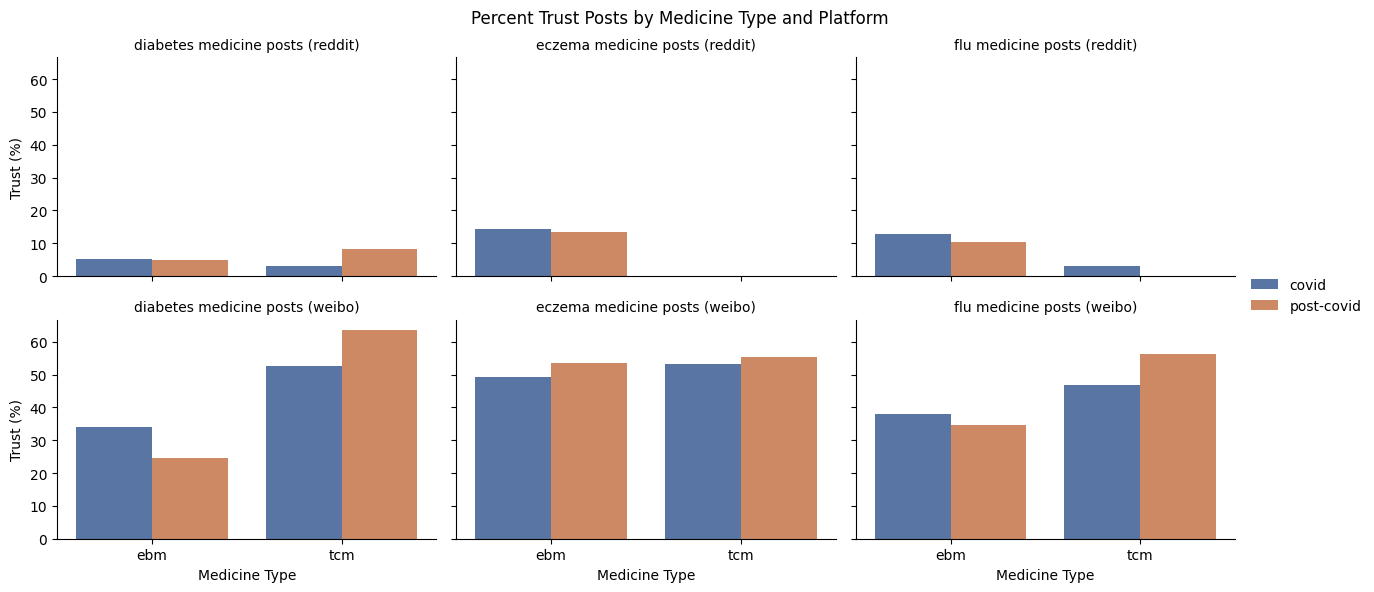

In [ ]:
g = sns.FacetGrid(covid_trust_df, row='source', col='medicine_category', height=3, aspect=1.4)
g.map_dataframe(
    sns.barplot, x='medicine_type', y='trust',
    hue='period', hue_order=["covid", "post-covid"],
    palette='deep'
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("Medicine Type")
g.set_ylabels("Trust (%)")
g.fig.suptitle("Percent Trust Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/ml/trust_covid_positives.png", dpi=310)

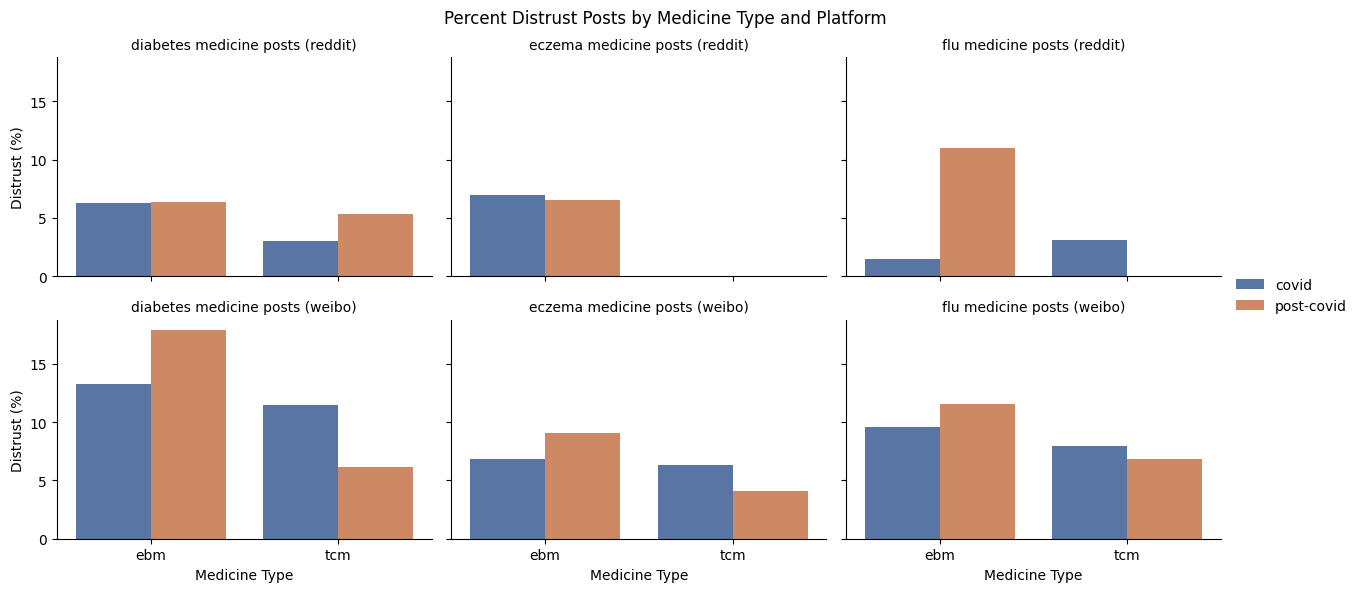

In [ ]:
g = sns.FacetGrid(covid_trust_df, row='source', col='medicine_category', height=3, aspect=1.4)
g.map_dataframe(
    sns.barplot, x='medicine_type', y='distrust',
    hue='period', hue_order=["covid", "post-covid"],
    palette='deep'
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("Medicine Type")
g.set_ylabels("Distrust (%)")
g.fig.suptitle("Percent Distrust Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/ml/trust_covid_negatives.png", dpi=310)

### Is there a difference between COVID and post-COVID opinions on the same types of medicines?

In [38]:
conds = covid_trust_df[['source', 'medicine_category', 'medicine_type']].drop_duplicates()
pvals = []
zstats = []
for i, series in conds.iterrows():
    source, med_cat, med_type = series
    df = covid_trust_df.query("source==@source and medicine_category==@med_cat and medicine_type==@med_type")
    successes = (df[df['period']=='covid']['trust_count'].iloc[0], df[df['period']=='post-covid']['trust_count'].iloc[0])
    counts = (df[df['period']=='covid']['count'].iloc[0], df[df['period']=='post-covid']['count'].iloc[0])
    stat, pval = proportions_ztest(successes, counts, alternative="two-sided")
    zstats.append(stat)
    pvals.append(pval)

/home/reptiman/miniconda3/envs/complit-4300/lib/python3.14/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


positive z values: covid > post-covid

In [39]:
conds['pval_two_sided'] = pvals
conds['z_stat_two_sided'] = zstats
conds['sig_two_sided'] = conds['pval_two_sided'] < (ALPHA/conds.shape[0])
conds

,source,medicine_category,medicine_type,pval_two_sided,z_stat_two_sided,sig_two_sided
0,reddit,diabetes,ebm,9.192175e-01,0.101419,False
2,reddit,diabetes,tcm,2.892270e-01,-1.059819,False
4,reddit,eczema,ebm,6.646031e-01,0.433567,False
6,reddit,eczema,tcm,NaN,NaN,False
8,reddit,flu,ebm,5.045615e-01,0.667330,False
10,reddit,flu,tcm,6.607882e-01,0.438825,False
12,weibo,diabetes,ebm,7.995590e-04,3.352947,True
14,weibo,diabetes,tcm,1.240645e-04,-3.837952,True
16,weibo,eczema,ebm,1.259092e-02,-2.495135,False
18,weibo,eczema,tcm,5.631675e-01,-0.578143,False


In [40]:
conds.to_csv("results/ml/longitudinal_trust_change_stats.csv", index=False)

### Is there a difference between post-COVID opinions on EBM vs. TCM?

In [41]:
post_covid = covid_trust_df[covid_trust_df['period']=="post-covid"]
conds = post_covid[['source', 'medicine_category']].drop_duplicates()
pvals = []
zstats = []
for i, series in conds.iterrows():
    source, med_cat = series
    df = post_covid.query("source==@source and medicine_category==@med_cat")
    successes = (df[df['medicine_type']=='tcm']['trust_count'].iloc[0], df[df['medicine_type']=='ebm']['trust_count'].iloc[0])
    counts = (df[df['medicine_type']=='tcm']['count'].iloc[0], df[df['medicine_type']=='ebm']['count'].iloc[0])
    stat, pval = proportions_ztest(successes, counts, alternative="two-sided")
    zstats.append(stat)
    pvals.append(pval)

Positive z values: tcm > ebm

In [42]:
conds['pval_two_sided'] = pvals
conds['z_stat_two_sided'] = zstats
conds['sig_two_sided'] = conds['pval_two_sided'] < (ALPHA/conds.shape[0])
conds

,source,medicine_category,pval_two_sided,z_stat_two_sided,sig_two_sided
1,reddit,diabetes,5.609929e-02,1.910264,False
5,reddit,eczema,4.976874e-01,-0.678133,False
9,reddit,flu,4.044373e-01,-0.833723,False
13,weibo,diabetes,2.917435e-91,20.259699,True
17,weibo,eczema,5.444115e-01,0.606156,False
21,weibo,flu,9.881805e-67,17.257181,True


In [43]:
conds.to_csv("results/ml/trust_tcm_vs_ebm_postcovid_stats.csv", index=False)

### Is there a difference between post-COVID opinion polarization on Weibo vs. Reddit?

#### Is the ratio of (positive TCM / positive EBM) different between platforms?

In [44]:
post_covid = covid_trust_df[covid_trust_df['period']=="post-covid"]
conds = post_covid[['medicine_category']].drop_duplicates()
pvals = []
print(f"Significance level = {ALPHA / conds.shape[0]}")
for i, series in conds.iterrows():
    med_cat = series['medicine_category']
    df = post_covid.query("medicine_category==@med_cat")
    weibo = df[df['source'] == 'weibo']
    reddit = df[df['source'] == 'reddit']
    contingency_table = [
        [weibo[weibo['medicine_type']=='tcm']['trust_count'].iloc[0], weibo[weibo['medicine_type']=='ebm']['trust_count'].iloc[0]], # Weibo Positive Posts
        [reddit[reddit['medicine_type']=='tcm']['trust_count'].iloc[0], reddit[reddit['medicine_type']=='ebm']['trust_count'].iloc[0]]  # Reddit Positive Posts
    ]
    chi2, pval, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"<======== {med_cat} | p-value: {np.round(pval, 4)} | sig = {pval < ALPHA / conds.shape[0]} ========>")
    print(pd.DataFrame(contingency_table, index=['weibo', 'reddit'], columns=['tcm', 'ebm']))
    print(pd.DataFrame(np.round(expected).astype(int), index=['weibo', 'reddit'], columns=['tcm', 'ebm']))
    pvals.append(pval)

Significance level = 0.016666666666666666
<======== diabetes | p-value: 0.0 | sig = True ========>
         tcm  ebm
weibo   1349  245
reddit    14  142
         tcm  ebm
weibo   1241  353
reddit   122   34
<======== eczema | p-value: 0.0 | sig = True ========>
        tcm   ebm
weibo   215  2138
reddit    0   207
        tcm   ebm
weibo   198  2155
reddit   17   190
<======== flu | p-value: 0.0 | sig = True ========>
         tcm   ebm
weibo   1280  1674
reddit     0   270
         tcm   ebm
weibo   1173  1781
reddit   107   163


#### Is the difference in post-COVID trust in TCM vs. EBM different by platform?

In [46]:
COVID_CUTOFF = 2023
trust_df = pd.read_csv("corpus/metadata_with_absa_scores_and_trust.csv")
trust_df['period'] = (trust_df['created_year'] > COVID_CUTOFF).apply(lambda x: "post-covid" if x else "covid")
post_covid_trust = trust_df[trust_df['period'] == 'post-covid']
post_covid_trust = post_covid_trust[['id', 'trust', 'source', 'medicine_category', 'medicine_type']]
post_covid_trust.head(2)

,id,trust,source,medicine_category,medicine_type
0,34344,Neutral,reddit,diabetes,ebm
1,15129,Neutral,weibo,flu,ebm


In [47]:
def calc_proportions(df, groupby_cols):
    pos_df = df.groupby(
        by=groupby_cols
    )['trust'].agg(lambda x: sum(x=='Trust')).to_frame().reset_index().rename(columns = {"trust": "trust_count"})
    neg_df = df.groupby(
        by=groupby_cols
    )['trust'].agg(lambda x: sum(x=='Distrust')).to_frame().reset_index().rename(columns = {"trust": "distrust_count"})
    count_df = df.groupby(
        by=groupby_cols
    )['trust'].agg('count').to_frame().reset_index().rename(columns = {"trust": "count"})
    category_df = pd.merge(pos_df, neg_df, on=groupby_cols, how='inner')
    category_df = pd.merge(category_df, count_df, on=groupby_cols, how='inner')
    category_df['pos_p'] = category_df['trust_count'] / category_df['count']
    category_df['neg_p'] = category_df['distrust_count'] / category_df['count']
    return category_df

In [48]:
def calc_pos_p_diff(metadata):
    groupby_cols = ['source', 'medicine_category', 'medicine_type']
    df = calc_proportions(metadata, groupby_cols=groupby_cols)
    df = df.pivot_table(index=['source', 'medicine_category'], columns='medicine_type', values='pos_p').reset_index()
    df['tcm-ebm'] = df['tcm'] - df['ebm']
    return df[['source', 'medicine_category', 'tcm-ebm']]

In [49]:
def calc_did(metadata):
    df = calc_pos_p_diff(metadata)
    df = df.pivot_table(index='medicine_category', columns='source', values='tcm-ebm').reset_index()
    df['weibo-reddit_tcm-ebm'] = df['weibo'] - df['reddit']
    return df

In [51]:
emp_df = calc_did(post_covid_trust)
emp_df

source,medicine_category,reddit,weibo,weibo-reddit_tcm-ebm
0,diabetes,0.033561,0.389242,0.355681
1,eczema,-0.132948,0.016053,0.149001
2,flu,-0.103846,0.216574,0.320420


In [52]:
n_permutes = 999
rng = np.random.default_rng(42)
emp_df = calc_did(post_covid_trust)
for i in tqdm(range(n_permutes)):
    permuted_md = post_covid_trust.copy()
    permuted_md['source'] = post_covid_trust['source'].sample(
        n=len(post_covid_trust['source']), replace=False, random_state = rng
    ).to_list()
    null_df = calc_did(permuted_md)[['medicine_category', 'weibo-reddit_tcm-ebm']]
    null_df = null_df.rename(columns = {'weibo-reddit_tcm-ebm': f'null_{i}'})
    emp_df = pd.merge(emp_df, null_df, on='medicine_category')

  0%|          | 0/999 [00:00<?, ?it/s]

In [53]:
p_vals = []
null_means = []
null_stds = []
for i, series in emp_df.iterrows():
    emp_dp = series['weibo-reddit_tcm-ebm']
    null_dps = series[[f"null_{i}" for i in range(n_permutes)]]
    n_ge = sum(abs(null_dps) >= abs(emp_dp))
    p_val = (n_ge+1)/(n_permutes+1)
    null_mean = null_dps.mean()
    null_std = null_dps.std()
    p_vals.append(p_val)
    null_means.append(null_mean)
    null_stds.append(null_std)

In [54]:
dp_df = emp_df[['medicine_category', 'weibo-reddit_tcm-ebm']].copy()
dp_df['p_val'] = p_vals
dp_df['null_mean'] = null_means
dp_df['null_std'] = null_stds
dp_df

source,medicine_category,weibo-reddit_tcm-ebm,p_val,null_mean,null_std
0,diabetes,0.355681,0.001,0.000094,0.023432
1,eczema,0.149001,0.011,0.000825,0.056032
2,flu,0.320420,0.001,-0.000231,0.025005


In [55]:
dp_df.to_csv("results/ml/trust_did_by_med_category.csv", index=False)